In [1]:
"""
Aperiodic (1/f) Parameterization of NREM Sleep EEG in IESS
============================================================
 
Purpose
-------
Complements the band-power / PAC findings in the pilot study by decomposing
each Welch power spectrum into:
    (1) an APERIODIC component  -> offset, exponent (and knee, if used)
    (2) a PERIODIC component    -> list of (center freq, power, bandwidth) peaks
 
This lets you test whether the treatment-related changes in theta/alpha/sigma/
gamma/delta power (Pre -> Post1 -> Post2) reflect genuine oscillatory
reorganization, a broadband tilt of the aperiodic slope, or both. It also
gives you an independent, biologically interpretable marker (aperiodic
exponent, linked to cortical E/I balance) to report alongside SWI and PAC.
 
Requirements
------------
pip install --break-system-packages mne specparam pandas scipy statsmodels
 
Expected input
--------------
Each EDF file IS a single, pre-confirmed 30-second N2 epoch -- one file per
subject per timepoint (no embedded annotations, no multi-epoch scoring to
extract). 4 subjects x 3 timepoints (Pre/Post1/Post2) = 12 files total.
 
Known data issues this version explicitly handles:
  1. Files are RAW (not artifact-cleaned) -- see the QC/visual-inspection
     step below. With only 12 files, visually inspecting each is realistic
     and recommended over trusting an automated threshold blind.
  2. Channel montage differs across timepoints/recording systems (e.g. one
     file had 46 channels, another 103) -- this script restricts every fit
     to the INTERSECTION of channel names present across all files, so
     comparisons across timepoints use only channels that exist everywhere.
 
Directory / manifest convention assumed here (adjust as needed):
    manifest.csv with columns: subject, timepoint, filepath
    e.g.
        subject,timepoint,filepath
        S01,Pre,/data/S01_Pre.edf
        S01,Post1,/data/S01_Post1.edf
        S01,Post2,/data/S01_Post2.edf
        S02,Pre,/data/S02_Pre.edf
        ...
"""

'\nAperiodic (1/f) Parameterization of NREM Sleep EEG in IESS\n============================================================\n\nPurpose\n-------\nComplements the band-power / PAC findings in the pilot study by decomposing\neach Welch power spectrum into:\n    (1) an APERIODIC component  -> offset, exponent (and knee, if used)\n    (2) a PERIODIC component    -> list of (center freq, power, bandwidth) peaks\n\nThis lets you test whether the treatment-related changes in theta/alpha/sigma/\ngamma/delta power (Pre -> Post1 -> Post2) reflect genuine oscillatory\nreorganization, a broadband tilt of the aperiodic slope, or both. It also\ngives you an independent, biologically interpretable marker (aperiodic\nexponent, linked to cortical E/I balance) to report alongside SWI and PAC.\n\nRequirements\n------------\npip install --break-system-packages mne specparam pandas scipy statsmodels\n\nExpected input\n--------------\nEach EDF file IS a single, pre-confirmed 30-second N2 epoch -- one file pe

In [2]:
import warnings
import numpy as np
import pandas as pd
import mne
from scipy.signal import butter, lfilter, iirnotch, hilbert, welch
from scipy.ndimage import gaussian_filter1d
from specparam import SpectralModel
from specparam.bands import Bands
from specparam.data.periodic import get_band_peak_arr
 
# NumPy 2.0 renamed trapz -> trapezoid; support either installed version
_trapz = getattr(np, "trapezoid", None) or np.trapz
 
mne.set_log_level("WARNING")
warnings.filterwarnings("ignore")

In [3]:
# ----------------------------------------------------------------------
# 1. CONFIGURATION -- match these to your study
# ----------------------------------------------------------------------
 
MANIFEST_CSV = "manifest.csv"          # subject, timepoint, filepath
OUTPUT_CSV = "aperiodic_results.csv"
 
# Frequency range to fit. Extended to 70 Hz to match the real pipeline's
# gamma band (30-70 Hz) and its 0.5-70 Hz bandpass ceiling exactly -- see
# NOTCH_EXCLUDE_HALFWIDTH below for how the 60/120 Hz notch dips (which
# would otherwise sit inside this range and distort the fit) are handled.
FIT_FREQ_RANGE = (1.0, 70.0)
 
# Welch PSD parameters. For 30-s epochs, a 4-s window with 50% overlap gives
# ~0.25 Hz resolution -- fine enough to resolve delta/theta/alpha peaks
# without being noisy. Matches compute_psd()/extract_band_powers_eses() in
# the real pipeline exactly.
WELCH_N_FFT = None       # set to sfreq*4 once sfreq is known (done per-file below)
WELCH_N_OVERLAP_FRAC = 0.5
 
# Band definitions -- copied EXACTLY from BANDS_ESES in eses_preprocess.py,
# not our earlier guessed 8-band scheme. Note delta (0.5-4) and slow_delta
# (0.5-2) intentionally overlap -- delta is the broad band, slow_delta the
# low sub-band; this matches the real pipeline's (and your original
# abstract's) definitions, not a bug.
BANDS_ESES = {
    "slow_delta": (0.5, 2.0),
    "delta": (0.5, 4.0),
    "spike_wave": (1.5, 3.5),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "sigma": (11.0, 16.0),
    "beta": (15.0, 30.0),
    "gamma": (30.0, 70.0),
}
BANDS = Bands(BANDS_ESES)
 
# Real pipeline's notch frequencies (60/120/180 Hz, matching load_single_epoch
# above). A notch filter carves a narrow dip at each of these frequencies --
# since 60 Hz sits inside the gamma band (30-70), leaving that dip in the
# specparam fit input can distort the aperiodic estimate. Excluded from the
# fit input by removing bins within +/- this many Hz of each notch frequency
# (a standard, documented approach for handling notch regions in FOOOF/
# specparam fits) -- NOT excluded from extract_band_powers_eses(), which
# matches the real pipeline's trapz-integration behavior exactly (they do
# not special-case the notch region either).
NOTCH_EXCLUDE_HALFWIDTH = 2.0
 
# Whether to fit with a "knee" term (recommended when the spectrum isn't a
# clean straight line in log-log space across your full fit range, which is
# common in pediatric EEG with a sigma/spindle hump). Try 'fixed' first and
# inspect residuals/reports; switch to 'knee' if fits look poor at low freq.
# With the fit range now extended to 70 Hz, 'knee' is more likely to be
# needed than before -- check model.plot() on a few real fits.
APERIODIC_MODE = "fixed"   # or "knee"
 

In [4]:
# ----------------------------------------------------------------------
# 2. DATA LOADING -- single pre-confirmed 30-s N2 epoch per file
# ----------------------------------------------------------------------

# Some of your recordings use the OLDER 10-20 temporal electrode names
# (T3/T4/T5/T6) instead of the newer 10-10 equivalents (T7/T8/P7/P8) --
# same physical electrode positions, different naming convention, seen on
# your lower-density montages specifically. Renamed on load so both
# conventions resolve to one canonical name before channel-set validation.
CHANNEL_ALIASES = {
    "T3": "T7",
    "T4": "T8",
    "T5": "P7",
    "T6": "P8",
}


# --- Corrected to match the actual SunLab eses_preprocess.py pipeline ---
# (confirmed via the real preprocessing script shared by collaborators).
# Three real changes vs. our earlier ad hoc version:
#   1. Bad-channel thresholds are much more permissive than what we guessed
#      (saturation checked on RAW unfiltered signal, not filtered/ptp-based)
#   2. Re-referencing to linked mastoid (A1+A2)/2 was missing entirely --
#      A1/A2 are reference-only in the real pipeline, never analyzed as
#      data channels
#   3. Filtering is a true 0.5-70 Hz bandpass + 60/120/180 Hz notch, not
#      just an unbounded highpass

# Bad-channel thresholds, matching eses_preprocess.py exactly (checked on
# the RAW signal in microvolts, before any filtering/referencing)
SAT_THRESH_UV = 3000.0    # peak |amplitude| above this -> saturated/bad
FLAT_THRESH_UV = 0.5      # RMS (std) below this -> flat/dead channel

# Reference electrodes used for linked-mastoid re-referencing. Never
# analyzed as data channels themselves (matches _NON_EEG in the real
# pipeline, which also excludes T1/T2/CS2 -- already excluded from
# SCALP_CHANNELS below for other reasons).
REREF_CHANNELS = ("A1", "A2")


# Real pipeline's bandpass + notch (order=4 Butterworth, zero-phase;
# MNE's raw.filter/notch_filter defaults are also zero-phase, different
# implementation, functionally equivalent for this purpose)
BANDPASS_HZ = (0.5, 70.0)

# Exact port of NYQUIST_GUARD from eeg_preprocess.py -- keep filters <= 95%
# of Nyquist to avoid edge artefacts. Used by the main bandpass/notch below
# AND by the PAC bandpass filters (_bandpass_pac), matching the real
# pipeline's shared use of this constant across both modules.
NYQUIST_GUARD = 0.95


def _zerophase(b, a, x):
    """
    Zero-phase filter: forward lfilter then reverse lfilter (== filtfilt).
    Exact port of _zerophase() in eeg_preprocess.py -- shared by the main
    bandpass/notch filtering (load_single_epoch) and PAC band-pass
    filtering (_bandpass_pac), matching how the real pipeline imports this
    same function into both eses_preprocess.py and pac_analysis.py.
    """
    y = lfilter(b, a, x)
    return lfilter(b, a, y[::-1])[::-1]


def _match_channels_ci(wanted, available):
    """
    Case-insensitive channel matching. SCALP_CHANNELS is stored in all
    caps (e.g. "CZ", "FP1"), but MNE actually reads/stores these as mixed
    case ("Cz", "Fp1") -- a plain `ch in available` check silently drops
    every channel whose real name has a lowercase letter (Cz, Fz, Pz, Fp1,
    Fp2 -- confirmed via testing to be exactly the channels lost this way).

    Returns the ACTUAL names from `available` (preserving their real
    case) for every entry in `wanted` that matches case-insensitively --
    use this instead of `[ch for ch in wanted if ch in available]`
    anywhere channels_to_use / SCALP_CHANNELS is compared against
    raw.ch_names.
    """
    available_upper = {ch.upper(): ch for ch in available}
    return [available_upper[w.upper()] for w in wanted if w.upper() in available_upper]
NOTCH_FREQS = [60.0, 120.0, 180.0]


def load_single_epoch(filepath, bandpass=BANDPASS_HZ, notch_freqs=NOTCH_FREQS,
                       reref_channels=REREF_CHANNELS,
                       sat_thresh=SAT_THRESH_UV, flat_thresh=FLAT_THRESH_UV):
    """
    Load one EDF file. Each file represents one N2-sleep clip -- its ENTIRE
    duration is analyzed, whatever that duration actually is.

    CONFIRMED via run_dataset_eses.py (the real orchestration script):
    process_all() calls load_edf() then passes the result DIRECTLY to
    analyze_clip() -- no duration check, no cropping, no trimming anywhere.
    Actual file durations vary (31.5-36.0s across your 12 files, confirmed
    via testing) and this is expected, not an error -- "30-second N2 epoch"
    was informal shorthand, not a literal fixed duration enforced anywhere
    in the real pipeline. An earlier version of this function applied a
    center-crop to exactly 30.0s; that was based on an incorrect assumption
    and has been removed to match the real pipeline's actual behavior.

    Applies, in order (matching eses_preprocess.py):
      1. CHANNEL_ALIASES     -- old/new 10-20 temporal naming -> canonical name
      2. Bad-channel check   -- saturation/flat on the RAW signal (see
                                SAT_THRESH_UV / FLAT_THRESH_UV). Bad channels
                                are dropped before re-referencing/filtering.
      3. Linked-mastoid reref -- (A1+A2)/2, matching the real pipeline. A1/A2
                                themselves are then dropped (reference-only,
                                never analyzed as data channels).
      4. Bandpass + notch    -- 0.5-70 Hz bandpass, 60/120/180 Hz notch.

    Returns
    -------
    raw : mne.io.Raw
    bad_channels : dict {channel_name: reason} flagged and dropped
    """
    raw = mne.io.read_raw_edf(filepath, preload=True)
    raw.pick("eeg")

    # case-insensitive alias application
    rename_map = {}
    for ch in raw.ch_names:
        canonical = CHANNEL_ALIASES.get(ch.upper())
        if canonical is not None:
            rename_map[ch] = canonical
    if rename_map:
        raw.rename_channels(rename_map)

    # --- restrict to the real scalp EEG channel set BEFORE the bad-channel
    # check. raw.pick("eeg") above relies on the EDF's channel-type
    # metadata, which does NOT reliably exclude PSG channels (ECG, chin
    # EMG, EOG, respiratory belts, SpO2, DC-offset channels, etc.) --
    # confirmed via testing: those showed up getting flagged as
    # "saturated"/"flat" against the 3000 uV / 0.5 uV EEG-specific
    # thresholds, which is meaningless for a respiratory or ECG signal.
    # The real pipeline avoids this via a custom edf_reader.py that
    # separates eeg_labels at read time; this does the equivalent by
    # explicitly keeping only known scalp + reference channel names.
    expected_channels = set(ch.upper() for ch in SCALP_CHANNELS) | \
                         set(ch.upper() for ch in reref_channels)
    keep = [ch for ch in raw.ch_names if ch.upper() in expected_channels]
    raw.pick(keep)

    # --- bad-channel check on the RAW signal, via flag_bad_channels()
    # below (exact port of the real pipeline's function) ---
    data_uv = raw.get_data(units="uV")
    channels_dict = {ch: data_uv[i] for i, ch in enumerate(raw.ch_names)}
    bad_channels = flag_bad_channels(channels_dict, sat_thresh=sat_thresh,
                                      flat_thresh=flat_thresh)
    if bad_channels:
        raw.drop_channels(list(bad_channels.keys()))

    # --- linked-mastoid re-reference, then drop A1/A2 (reference-only) ---
    reref_method = "linked_mastoid"
    available_ref = _match_channels_ci(reref_channels, raw.ch_names)
    if available_ref:
        raw.set_eeg_reference(ref_channels=available_ref, verbose=False)
        raw.drop_channels(available_ref)
    else:
        # Both mastoids missing/bad (confirmed to occur in real data --
        # e.g. ELE03/Post1 has both A1 and A2 saturated). Matches
        # rereference_average() in the real pipeline: fall back to the
        # average of all remaining good scalp channels.
        reref_method = "average_fallback"
        print(f"  [{filepath}] both mastoid channels bad/missing -- "
              f"using average reference fallback instead of linked mastoid")
        raw.set_eeg_reference(ref_channels="average", verbose=False)

    # --- bandpass + notch: exact port of preprocess_eses() in the real
    # script, NOT MNE's raw.filter()/notch_filter(). This matters concretely:
    # MNE's default FIR filter for a 0.5 Hz cutoff needs a ~6.6-second
    # kernel (confirmed via testing), producing a highly visible multi-
    # second ringing transient right at the start of a 30-s clip -- a
    # dense, uniform high-frequency artifact across every channel
    # simultaneously, visible in raw.plot(). The real pipeline's 4th-order
    # Butterworth + custom zero-phase (forward+reverse lfilter) approach
    # settles in a fraction of a second instead (confirmed via testing
    # against the same synthetic signal) -- this is NOT a stylistic
    # difference, it materially changes how much of a short 30-s epoch is
    # usable.
    sfreq = raw.info["sfreq"]
    nyq = sfreq / 2.0
    data_v = raw.get_data()  # volts, MNE's native unit

    if bandpass is not None:
        lo_norm = bandpass[0] / nyq
        hi_norm = min(bandpass[1], nyq * NYQUIST_GUARD) / nyq
        b, a = butter(4, [lo_norm, hi_norm], btype="band")
        data_v = np.array([_zerophase(b, a, ch) for ch in data_v])

    if notch_freqs is not None:
        for nf in notch_freqs:
            if nf < nyq * NYQUIST_GUARD:
                bn, an = iirnotch(nf / nyq, 30)
                data_v = np.array([_zerophase(bn, an, ch) for ch in data_v])

    raw._data = data_v

    return raw, bad_channels


def find_common_channels(manifest_csv=None, manifest_df=None):
    """
    Scan every file in the manifest and return the intersection of channel
    names present in ALL of them. Useful as a first exploratory look, but
    note this can include non-scalp/auxiliary channels if your recording
    system has them. For the actual analysis, prefer a fixed, clinically
    -defined scalp set -- see SCALP_CHANNELS and validate_channel_set()
    below instead.
    """
    if manifest_df is None:
        manifest_df = pd.read_csv(manifest_csv)

    common = None
    per_file_channels = {}
    for _, row in manifest_df.iterrows():
        raw, _ = load_single_epoch(row["filepath"])  # applies CHANNEL_ALIASES
        chs = set(ch.upper() for ch in raw.ch_names)  # case-insensitive match
        per_file_channels[f"{row['subject']}_{row['timepoint']}"] = chs
        common = chs if common is None else (common & chs)

    print("Channels present in EVERY file (intersection):")
    print(sorted(common))
    print(f"\n{len(common)} common channels out of "
          f"{max(len(c) for c in per_file_channels.values())} max seen in any single file.")

    for name, chs in per_file_channels.items():
        missing = common - chs if common else set()
        if missing:
            print(f"  (sanity check) {name} is missing: {missing}")  # should be empty by construction

    return sorted(common)


# Fixed, clinically-defined scalp channel set (standard 10-20 positions).
# NOTE: OZ, FPZ, T1, T2 dropped -- genuinely absent (not a naming issue) in
# several files even after alias correction. A1, A2 removed separately --
# per the real eses_preprocess.py pipeline, these are reference-only
# (linked-mastoid re-referencing target) and are never analyzed as data
# channels themselves; load_single_epoch() already drops them after reref.
SCALP_CHANNELS = [
    "C3", "C4", "CZ",
    "F3", "F4", "F7", "F8", "FZ",
    "FP1", "FP2",
    "O1", "O2",
    "P3", "P4", "P7", "P8", "PZ",
    "T7", "T8",
]


def validate_channel_set(manifest_csv=None, manifest_df=None, channel_set=SCALP_CHANNELS):
    """
    Check that every file in the manifest actually has every channel in
    `channel_set`, AFTER alias correction (see CHANNEL_ALIASES / 
    load_single_epoch). Prints per-file gaps so you catch genuine absences
    versus naming mismatches before they silently drop a channel from one
    file's fit.

    Returns the channel_set unchanged (for convenience / chaining), but
    you should read the printed output before trusting it.
    """
    if manifest_df is None:
        manifest_df = pd.read_csv(manifest_csv)

    target = set(ch.upper() for ch in channel_set)
    all_ok = True
    for _, row in manifest_df.iterrows():
        raw, _ = load_single_epoch(row["filepath"])  # applies CHANNEL_ALIASES
        present = set(ch.upper() for ch in raw.ch_names)
        missing = target - present
        label = f"{row['subject']} / {row['timepoint']}"
        if missing:
            all_ok = False
            print(f"  MISSING in {label}: {sorted(missing)}")
        else:
            print(f"  OK: {label} has all {len(target)} channels")

    if all_ok:
        print(f"\nAll files contain all {len(target)} channels in the requested set.")
    else:
        print("\nSome files are missing channels above -- check for naming "
              "differences before assuming they're truly absent.")

    return channel_set


def inspect_raw_for_qc(filepath, duration=30.0):
    """
    Visual QC helper. Opens an interactive plot (run in a notebook cell).
    Note channels/segments that look artifactual; feed that into the
    `exclude` dict in run_pipeline().
    """
    raw, dropped_channels = load_single_epoch(filepath)
    raw.plot(duration=duration, n_channels=20, scalings="auto", block=False)
    return raw


In [5]:
# ----------------------------------------------------------------------
# 2b. ARTIFACT DETECTION -- exact port of flag_bad_channels() from the
# real eses_preprocess.py, replacing our earlier custom PTP/kurtosis
# thresholds entirely (those didn't match the validated methodology --
# this does).
# ----------------------------------------------------------------------

def flag_bad_channels(channels, sat_thresh=SAT_THRESH_UV, flat_thresh=FLAT_THRESH_UV):
    """
    Flag channels with saturation or flat-line artefacts. Direct port of
    flag_bad_channels() in eses_preprocess.py -- same signature, same
    logic, same reason strings ('saturated', 'flat', 'saturated+flat').

    Parameters
    ----------
    channels : dict {label: 1-D np.ndarray in microvolts}

    Returns
    -------
    dict {label: reason} -- only bad channels included.
    """
    bad = {}
    for lb, sig in channels.items():
        reasons = []
        if np.max(np.abs(sig)) > sat_thresh:
            reasons.append("saturated")
        if np.std(sig) < flat_thresh:
            reasons.append("flat")
        if reasons:
            bad[lb] = "+".join(reasons)
    return bad


def run_qc_summary(manifest_csv=MANIFEST_CSV, manifest_df=None):
    """
    Run the real bad-channel check (flag_bad_channels, via load_single_epoch)
    across every file in the manifest and print a per-file summary.

    Note: load_single_epoch() already applies this check and drops flagged
    channels automatically -- this function exists purely for visibility
    (so you can see what got dropped and why, across the whole dataset,
    before running the full pipeline) rather than to produce a separate
    exclude list. If you find additional bad channels via visual review
    (inspect_raw_for_qc) that the amplitude/flat check doesn't catch,
    those still go in run_pipeline(exclude=...) by hand.

    Returns
    -------
    dropped_df : DataFrame, one row per (subject, timepoint, channel, reason)
    """
    if manifest_df is None:
        manifest_df = pd.read_csv(manifest_csv)

    all_dropped = []
    for _, row in manifest_df.iterrows():
        subject, timepoint, filepath = row["subject"], row["timepoint"], row["filepath"]
        raw, dropped_channels = load_single_epoch(filepath)

        for ch_name, reason in dropped_channels.items():
            all_dropped.append({
                "subject": subject, "timepoint": timepoint,
                "channel": ch_name, "reason": reason,
            })

        label = f"{subject} / {timepoint}"
        if dropped_channels:
            print(f"  {label}: {len(dropped_channels)} channel(s) dropped -> {dropped_channels}")
        else:
            print(f"  {label}: clean (no bad channels)")

    dropped_df = pd.DataFrame(all_dropped)
    print(f"\nTotal dropped: {len(dropped_df)} channel-recordings across "
          f"{dropped_df[['subject','timepoint']].drop_duplicates().shape[0] if len(dropped_df) else 0} recordings")

    return dropped_df

In [6]:
# ----------------------------------------------------------------------
# 3. PSD COMPUTATION -- single continuous 30-s segment, per channel
# ----------------------------------------------------------------------

def compute_raw_psd(raw, channels_to_use=None):
    """
    Welch PSD computed directly on the single 30-s continuous signal
    (no epoch-averaging needed -- there is only one "epoch").

    Returns
    -------
    freqs : ndarray, shape (n_freqs,)
    psds  : ndarray, shape (n_channels, n_freqs)
    ch_names : list of channel names actually used
    """
    if channels_to_use is not None:
        # keep only channels that exist in this file AND are in the common set
        present = _match_channels_ci(channels_to_use, raw.ch_names)
        raw = raw.copy().pick(present)

    sfreq = raw.info["sfreq"]
    n_fft = int(sfreq * 4)          # 4-second Welch window
    n_overlap = int(n_fft * WELCH_N_OVERLAP_FRAC)

    # A single 30-s segment only fits ~7 non-overlapping 4-s windows (14-15
    # with 50% overlap) -- n_fft must not exceed the total number of samples.
    n_samples = raw.n_times
    n_fft = min(n_fft, n_samples)
    n_overlap = min(n_overlap, n_fft - 1)

    spectrum = raw.compute_psd(
        method="welch",
        fmin=0.5, fmax=75.0,   # covers real gamma band (30-70 Hz) with margin
        n_fft=n_fft, n_overlap=n_overlap,
    )
    psds, freqs = spectrum.get_data(return_freqs=True)  # (n_ch, n_freqs)
    return freqs, psds, raw.ch_names


def extract_band_powers_eses(freqs, psd, bands=None, normalize=True):
    """
    Direct replica of extract_band_powers_eses() in the real
    eses_preprocess.py: relative (or absolute) Welch band power via
    trapezoidal integration, NOT decomposed into periodic/aperiodic.

    Use this to get the same "raw" band-power numbers as the original
    published pipeline, for direct comparison against the specparam
    periodic-only band power from fit_aperiodic() below -- that comparison
    (raw vs. periodic-only power in the same band) is the actual answer to
    "does this band's change survive removing the aperiodic background".
    """
    if bands is None:
        bands = BANDS_ESES

    total = float(_trapz(psd, freqs))
    result = {}
    for name, (lo, hi) in bands.items():
        mask = (freqs >= lo) & (freqs <= hi)
        if not mask.any() or total == 0:
            result[name] = np.nan
            continue
        power = float(_trapz(psd[mask], freqs[mask]))
        result[name] = (power / total) if normalize else power
    return result


In [7]:

# ----------------------------------------------------------------------
# 3b. SWI + SWD/BACKGROUND SEGMENTATION -- exact port of compute_swi() and
# _extract_segmented_powers() from eses_preprocess.py
# ----------------------------------------------------------------------
# NOTE: extract_band_powers_eses() above computes power over the WHOLE
# clip. The real pipeline's published tables (TableA1_SWD_Power,
# TableA2_NREM_Power) instead split each clip into SWD segments (samples
# where the spike-wave envelope exceeds threshold) and background/NREM
# segments (below threshold), and report band power SEPARATELY for each
# -- confirmed by comparing TableA1 vs TableA2 directly (different means,
# very different sample counts). Without this split, raw band power isn't
# actually comparable to those published tables. This section adds it.

SWI_SW_BAND = (1.5, 3.5)
SWI_THRESH_FACTOR = 2.5
SWI_SMOOTH_MS = 200.0
MIN_SEGMENT_SECONDS = 2.0  # minimum segment length for a valid Welch estimate


def compute_swi(eeg, fs, sw_band=SWI_SW_BAND, thresh_factor=SWI_THRESH_FACTOR,
                 smooth_ms=SWI_SMOOTH_MS):
    """
    Spike-wave index for one channel. Exact port of compute_swi().

    Method: bandpass to sw_band -> Hilbert envelope -> Gaussian-smooth
    (200ms FWHM) -> threshold = thresh_factor * median(envelope) ->
    SWI = fraction of samples above threshold.

    Parameters
    ----------
    eeg : 1-D EEG (uV), re-referenced and broadband-filtered
    fs  : sampling rate (Hz)

    Returns
    -------
    dict with keys: swi, swi_pct, mean_env_uv, thresh_uv, sw_duration_s,
    sw_filtered, envelope (the last two are arrays, needed for segmentation)
    """
    eeg = np.asarray(eeg, dtype=np.float64)
    nyq = fs / 2.0

    lo = sw_band[0] / nyq
    hi = min(sw_band[1], nyq * NYQUIST_GUARD) / nyq
    b, a = butter(4, [lo, hi], btype="band")
    sw_sig = _zerophase(b, a, eeg)

    env = np.abs(hilbert(sw_sig))

    if smooth_ms > 0:
        sigma = (smooth_ms / 1000.0) * fs / 2.355  # FWHM -> sigma in samples
        env = gaussian_filter1d(env, sigma=sigma)

    thresh = thresh_factor * float(np.median(env))
    above = env > thresh
    swi = float(np.mean(above))
    sw_dur = float(np.sum(above)) / fs

    return {
        "swi": swi, "swi_pct": swi * 100.0,
        "mean_env_uv": float(np.mean(env)), "thresh_uv": thresh,
        "sw_duration_s": sw_dur,
        "sw_filtered": sw_sig.astype(np.float32),
        "envelope": env.astype(np.float32),
        "above_mask": above,
    }


def _extract_segmented_powers(eeg, above_mask, fs, min_seconds=MIN_SEGMENT_SECONDS):
    """
    Welch band powers computed separately on SWD samples (above_mask=True)
    and background samples (above_mask=False). Exact port of
    _extract_segmented_powers(). Samples are concatenated (not contiguous
    epochs) -- matches the real pipeline's own documented caveat about the
    implicit stationarity assumption.

    Returns
    -------
    (swd_powers, bg_powers) -- each {band_name: relative_power}, NaN if
    the segment is too short for a valid Welch estimate.
    """
    nyq = fs / 2.0
    min_samples = int(min_seconds * fs)
    bands = {name: (lo, hi) for name, (lo, hi) in BANDS_ESES.items()
             if hi < nyq * NYQUIST_GUARD}

    def _welch_powers(samples):
        n = len(samples)
        if n < min_samples:
            return {b: float("nan") for b in bands}
        nperseg = min(int(4.0 * fs), n)
        noverlap = nperseg // 2
        freqs, psd = welch(samples, fs=fs, nperseg=nperseg, noverlap=noverlap,
                            window="hann", scaling="density")
        total = float(_trapz(psd, freqs))
        result = {}
        for name, (lo, hi) in bands.items():
            mask = (freqs >= lo) & (freqs <= hi)
            if not mask.any() or total == 0:
                result[name] = float("nan")
            else:
                result[name] = float(_trapz(psd[mask], freqs[mask])) / total
        return result

    return _welch_powers(eeg[above_mask]), _welch_powers(eeg[~above_mask])


def run_segmented_analysis(manifest_csv=MANIFEST_CSV, channels_to_use=None,
                            swi_channel_only=False):
    """
    Run SWI + SWD/background-segmented band power AND PAC across every
    file/channel in the manifest -- this is what actually produces numbers
    comparable to TableA1/A2 (power) and TableB1/B2 (PAC).

    Parameters
    ----------
    swi_channel_only : if True, compute the SWI mask once per file using
        only the pipeline's preferred frontal channel (matching analyze_clip's
        single swi_channel selection for the headline SWI value), then
        apply that SAME mask to every channel's segmentation. If False
        (default), computes an independent SWI mask per channel -- closer
        to per_ch_swi in analyze_clip, which does compute SWI per channel.

    Returns
    -------
    swi_df        : one row per (subject, timepoint, channel) with swi_pct
    power_long_df : one row per (subject, timepoint, channel, band,
                    segment) with power, segment in {"SWD","NREM"}
    pac_long_df   : one row per (subject, timepoint, channel, phase_band,
                    amp_band, segment) with MI, segment in {"SWD","NREM"}
    """
    manifest = pd.read_csv(manifest_csv)
    swi_rows, power_rows, pac_rows = [], [], []

    for _, row in manifest.iterrows():
        subject, timepoint, filepath = row["subject"], row["timepoint"], row["filepath"]
        print(f"Segmented analysis: {subject} / {timepoint} ...")

        raw, bad = load_single_epoch(filepath)
        if channels_to_use is not None:
            present = _match_channels_ci(channels_to_use, raw.ch_names)
            raw = raw.copy().pick(present)

        data_uv = raw.get_data(units="uV")
        fs = raw.info["sfreq"]

        for ch_idx, ch_name in enumerate(raw.ch_names):
            sig = data_uv[ch_idx]
            swi_result = compute_swi(sig, fs)
            swi_rows.append({"subject": subject, "timepoint": timepoint,
                              "channel": ch_name, "swi_pct": swi_result["swi_pct"]})

            above_mask = swi_result["above_mask"]
            swd_powers, bg_powers = _extract_segmented_powers(sig, above_mask, fs)
            for band, val in swd_powers.items():
                power_rows.append({"subject": subject, "timepoint": timepoint,
                                    "channel": ch_name, "band": band,
                                    "segment": "SWD", "power": val})
            for band, val in bg_powers.items():
                power_rows.append({"subject": subject, "timepoint": timepoint,
                                    "channel": ch_name, "band": band,
                                    "segment": "NREM", "power": val})

            min_samples = int(MIN_SEGMENT_SECONDS * fs)
            swd_sig = sig[above_mask]
            bg_sig = sig[~above_mask]
            if len(swd_sig) >= min_samples:
                for r in compute_pac_channel(swd_sig, fs):
                    pac_rows.append({"subject": subject, "timepoint": timepoint,
                                      "channel": ch_name, "segment": "SWD", **r})
            if len(bg_sig) >= min_samples:
                for r in compute_pac_channel(bg_sig, fs):
                    pac_rows.append({"subject": subject, "timepoint": timepoint,
                                      "channel": ch_name, "segment": "NREM", **r})

    swi_df = pd.DataFrame(swi_rows)
    power_long_df = pd.DataFrame(power_rows)
    pac_long_df = pd.DataFrame(pac_rows)
    print(f"\nSWI rows: {len(swi_df)}, power rows: {len(power_long_df)}, "
          f"PAC rows: {len(pac_long_df)}")
    return swi_df, power_long_df, pac_long_df


In [8]:
# ----------------------------------------------------------------------
# 4. SPECPARAM (FOOOF) FITTING
# ----------------------------------------------------------------------

def _interpolate_notch_regions(freqs, psd, notch_freqs=NOTCH_FREQS,
                                halfwidth=NOTCH_EXCLUDE_HALFWIDTH):
    """
    Replace bins within `halfwidth` Hz of each notch frequency with a
    linear interpolation (in log-power space, appropriate for spectra)
    between the flanking clean bins.

    NOTE: specparam requires evenly-spaced frequencies and errors on a
    gapped array (confirmed via testing) -- so notch bins can't simply be
    deleted before fitting. Interpolating across them instead keeps the
    array evenly spaced while removing the distortion; tested against a
    known ground-truth spectrum and recovers aperiodic parameters close to
    the uncontaminated fit, vs. a visibly biased fit when the dip is left in.
    """
    psd_fixed = psd.copy()
    log_psd = np.log10(np.clip(psd_fixed, 1e-20, None))

    for nf in notch_freqs:
        mask = np.abs(freqs - nf) < halfwidth
        if not mask.any():
            continue
        idx = np.where(mask)[0]
        lo, hi = idx.min() - 1, idx.max() + 1
        if lo < 0 or hi >= len(freqs):
            continue  # notch too close to the edge of the fit range to interpolate
        log_psd[idx] = np.interp(freqs[idx], [freqs[lo], freqs[hi]],
                                  [log_psd[lo], log_psd[hi]])

    return 10 ** log_psd


def fit_aperiodic(freqs, psd_1d):
    """
    Fit one power spectrum (already averaged or single epoch/channel).

    Interpolates across notch-filter dips (60/120/180 Hz) before fitting --
    left in, these distort the aperiodic estimate (see
    _interpolate_notch_regions docstring); specparam can't simply have
    those bins removed since it requires evenly-spaced frequencies.

    Returns dict with aperiodic offset/exponent (+ knee if used) and,
    for convenience, per-band peak power extracted from the *periodic*
    component only (i.e. oscillatory power with the 1/f background removed).
    """
    psd_for_fit = _interpolate_notch_regions(freqs, psd_1d)

    model = SpectralModel(
        aperiodic_mode=APERIODIC_MODE,
        peak_width_limits=(1.0, 8.0),
        max_n_peaks=8,
        min_peak_height=0.05,
        peak_threshold=2.0,
        verbose=False,
    )
    model.fit(freqs, psd_for_fit, freq_range=FIT_FREQ_RANGE)

    out = {}
    ap_params = model.get_params("aperiodic")
    if APERIODIC_MODE == "knee":
        out["offset"], out["knee"], out["exponent"] = ap_params
    else:
        out["offset"], out["exponent"] = ap_params
        out["knee"] = np.nan

    metrics = model.results.metrics.results
    out["r_squared"] = metrics.get("gof_rsquared", np.nan)
    out["error"] = metrics.get("error_mae", np.nan)

    # Periodic (peak) power per band, aperiodic-corrected
    peak_params = model.get_params("peak")
    for band_name, band_range in BANDS:
        band_peak = get_band_peak_arr(peak_params, band_range, select_highest=True)
        # band_peak is [CF, PW, BW], filled with nan if no peak found in range
        out[f"periodic_{band_name}_cf"] = band_peak[0]
        out[f"periodic_{band_name}_power"] = band_peak[1]
        out[f"periodic_{band_name}_bw"] = band_peak[2]

    return out

In [9]:
# ----------------------------------------------------------------------
# 4b. PHASE-AMPLITUDE COUPLING (PAC) -- exact port of pac_analysis.py
# ----------------------------------------------------------------------
# Modulation Index (Tort et al. 2010). Included so you can reproduce the
# PAC numbers from your original published pipeline, not just the new
# aperiodic decomposition. Runs on the same re-referenced, broadband-
# filtered signal produced by load_single_epoch() -- matching the real
# pipeline's processing order (reref + broadband filter, THEN PAC).

# Phase-providing (slow) oscillations -- exact copy of PHASE_BANDS
PHASE_BANDS = {
    "spike_wave": (1.5, 3.5),   # ESES spike-wave carrier -- primary clinical target
    "delta": (0.5, 4.0),        # broad delta
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
}

# Amplitude-providing (fast) oscillations -- exact copy of AMP_BANDS.
# NOTE: gamma here is capped at 50 Hz for PAC specifically (narrower than
# the 30-70 Hz gamma used elsewhere in BANDS_ESES) -- this matches the
# real pac_analysis.py exactly, chosen there for Nyquist margin at 256 Hz
# sampling. Not a typo / inconsistency to "fix" -- it's their real value.
AMP_BANDS = {
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (15.0, 30.0),
    "gamma": (30.0, 50.0),
}


def _bandpass_pac(data, low_hz, high_hz, fs, order=3):
    """
    Butterworth bandpass via _zerophase, exact port of _bandpass_pac() in
    pac_analysis.py. Note order=3 here vs order=4 in the main preprocessing
    bandpass -- matches the real script's (undocumented but real) choice
    of a different filter order specifically for PAC band isolation.
    """
    nyq = fs / 2.0
    lo_norm = low_hz / nyq
    hi_norm = min(high_hz, nyq * NYQUIST_GUARD) / nyq

    if lo_norm <= 0.0 or hi_norm >= 1.0 or lo_norm >= hi_norm:
        raise ValueError(
            f"Invalid PAC bandpass ({low_hz}, {high_hz}) Hz for fs={fs} Hz "
            f"(Nyquist={nyq:.1f} Hz, guard={NYQUIST_GUARD})"
        )

    b, a = butter(order, [lo_norm, hi_norm], btype="band")
    return _zerophase(b, a, data)


def compute_mi(phase_rad, amp_envelope, n_bins=18):
    """
    Modulation Index (Tort et al. 2010). Exact port of compute_mi().

    Parameters
    ----------
    phase_rad    : instantaneous phase in radians (-pi to +pi)
    amp_envelope : amplitude envelope (non-negative)
    n_bins       : phase bins; 18 -> 20-degree bins (paper default)

    Returns
    -------
    float : MI in [0, 1]. 0 = amplitude uniform across phase (no coupling).
            -> 1 = amplitude concentrated at one phase bin (perfect coupling).
    """
    phase_deg = np.degrees(phase_rad) + 180.0
    bins = np.linspace(0.0, 360.0, n_bins + 1)

    bin_idx = np.digitize(phase_deg, bins) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    mean_amp = np.zeros(n_bins, dtype=np.float64)
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.any():
            mean_amp[b] = amp_envelope[mask].mean()

    total = mean_amp.sum()
    if total == 0.0:
        return 0.0

    P = mean_amp / total
    uniform = 1.0 / n_bins

    kl = sum(p * np.log(p / uniform) for p in P if p > 0.0)
    return float(kl / np.log(n_bins))


def compute_pac_channel(eeg, fs, phase_bands=None, amp_bands=None, n_bins=18):
    """
    PAC MI for all valid cross-frequency band pairs on one channel. Exact
    port of compute_pac_channel(). Only pairs where the amplitude band is
    strictly above the phase band are computed (genuine cross-frequency
    coupling; overlapping bands skipped).

    Parameters
    ----------
    eeg : 1-D EEG (uV), re-referenced and broadband-filtered (i.e. the
          signal returned by load_single_epoch(), converted to uV)
    fs  : sampling rate (Hz)

    Returns
    -------
    list of dicts with keys: 'phase_band', 'amp_band', 'MI'
    """
    if phase_bands is None:
        phase_bands = PHASE_BANDS
    if amp_bands is None:
        amp_bands = AMP_BANDS

    eeg = np.asarray(eeg, dtype=np.float64)
    nyq = fs / 2.0
    results = []

    for pname, (plo, phi) in phase_bands.items():
        if phi >= nyq * NYQUIST_GUARD:
            continue
        try:
            pfilt = _bandpass_pac(eeg, plo, phi, fs)
            inst_phase = np.angle(hilbert(pfilt))
        except Exception:
            continue

        for aname, (alo, ahi) in amp_bands.items():
            if alo <= phi:
                continue
            if ahi >= nyq * NYQUIST_GUARD:
                continue
            try:
                afilt = _bandpass_pac(eeg, alo, ahi, fs)
                inst_amp = np.abs(hilbert(afilt))
                mi = compute_mi(inst_phase, inst_amp, n_bins)
                results.append({"phase_band": pname, "amp_band": aname,
                                 "MI": round(mi, 6)})
            except Exception:
                pass

    return results


def run_pac_pipeline(manifest_csv=MANIFEST_CSV, output_csv="pac_results.csv",
                      channels_to_use=None):
    """
    Run PAC across every file/channel in the manifest, matching how
    analyze_clip() runs compute_pac_channel() per good channel. Produces a
    long-format DataFrame: one row per (subject, timepoint, channel,
    phase_band, amp_band) with its MI value.
    """
    manifest = pd.read_csv(manifest_csv)
    rows = []

    for _, row in manifest.iterrows():
        subject, timepoint, filepath = row["subject"], row["timepoint"], row["filepath"]
        print(f"PAC: {subject} / {timepoint} ...")

        raw, bad = load_single_epoch(filepath)
        if channels_to_use is not None:
            present = _match_channels_ci(channels_to_use, raw.ch_names)
            raw = raw.copy().pick(present)

        data_uv = raw.get_data(units="uV")
        fs = raw.info["sfreq"]

        for ch_idx, ch_name in enumerate(raw.ch_names):
            pac_results = compute_pac_channel(data_uv[ch_idx], fs)
            for r in pac_results:
                rows.append({
                    "subject": subject, "timepoint": timepoint,
                    "channel": ch_name, "phase_band": r["phase_band"],
                    "amp_band": r["amp_band"], "MI": r["MI"],
                })

    results_df = pd.DataFrame(rows)
    results_df.to_csv(output_csv, index=False)
    print(f"\nSaved {len(results_df)} PAC rows to {output_csv}")
    return results_df

In [10]:
# ----------------------------------------------------------------------
# 5. MAIN PIPELINE
# ----------------------------------------------------------------------

def run_pipeline(manifest_csv=MANIFEST_CSV, output_csv=OUTPUT_CSV,
                  channels_to_use=None, exclude=None):
    """
    Parameters
    ----------
    channels_to_use : list of str or None
        Restrict fitting to these channels (should be the common-channel
        intersection from find_common_channels(), possibly narrowed to a
        clinically-meaningful subset). If None, uses whatever channels
        exist in each file individually -- NOT recommended given the
        montage mismatch across your timepoints, since that makes
        cross-timepoint channel-level comparisons apples-to-oranges.
    exclude : dict or None
        Optional {(subject, timepoint): [bad_channel_names]} from your
        visual QC pass, to drop specific channels found to be artifactual
        in specific files.
    """
    manifest = pd.read_csv(manifest_csv)
    exclude = exclude or {}
    rows = []

    for _, row in manifest.iterrows():
        subject, timepoint, filepath = row["subject"], row["timepoint"], row["filepath"]
        print(f"Processing {subject} / {timepoint} ...")

        raw, dropped_channels = load_single_epoch(filepath)

        bad_this_file = exclude.get((subject, timepoint), [])
        if bad_this_file:
            present_bad = _match_channels_ci(bad_this_file, raw.ch_names)
            raw.drop_channels(present_bad)

        freqs, psds, ch_names = compute_raw_psd(raw, channels_to_use=channels_to_use)

        for ch_idx, ch_name in enumerate(ch_names):
            try:
                fit_result = fit_aperiodic(freqs, psds[ch_idx])
            except Exception as e:
                print(f"  fit failed for {ch_name}: {e}")
                continue
            fit_result.update({
                "subject": subject,
                "timepoint": timepoint,
                "channel": ch_name,
            })
            rows.append(fit_result)

    results_df = pd.DataFrame(rows)
    results_df.to_csv(output_csv, index=False)
    print(f"\nSaved {len(results_df)} rows to {output_csv}")
    return results_df

In [11]:
# ----------------------------------------------------------------------
# 6. STATISTICS -- Linear Mixed-Effects across Pre/Post1/Post2
# ----------------------------------------------------------------------

def run_lme(results_df, dependent_var="exponent"):
    """
    Per-channel LME: timepoint as a fixed effect, subject as a random
    effect. Treats every channel as a separate observation beyond the
    subject random intercept -- this OVERSTATES confidence, since
    channels within a subject's scalp are spatially correlated, not
    independent (pseudo-replication). Useful as an exploratory/spatial-
    consistency check, NOT as the primary reported statistic -- use
    run_lme_subject_averaged() below for that.
    """
    import statsmodels.formula.api as smf

    df = results_df.copy()
    df["timepoint"] = pd.Categorical(df["timepoint"], categories=["Pre", "Post1", "Post2"], ordered=True)

    model = smf.mixedlm(
        f"{dependent_var} ~ C(timepoint, Treatment(reference='Pre'))",
        data=df,
        groups=df["subject"],
    )
    try:
        result = model.fit()
        print(result.summary())
    except Exception as e:
        # Same numerical-degeneracy fallback as run_lme_subject_averaged --
        # see that function's docstring for why this can happen.
        print(f"  MixedLM failed to converge ({type(e).__name__}: {e}).")
        print("  Falling back to OLS with subject-clustered robust SEs.")
        ols_model = smf.ols(
            f"{dependent_var} ~ C(timepoint, Treatment(reference='Pre'))",
            data=df,
        )
        result = ols_model.fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
        print(result.summary())
    return result


def aggregate_by_subject(results_df, value_col="exponent"):
    """
    Collapse per-channel rows to one value per (subject, timepoint) by
    averaging across channels. This is the honest unit of replication for
    an n=4 study -- each subject contributes ONE number per timepoint,
    not 19 (one per channel).

    Returns a DataFrame with columns: subject, timepoint, <value_col>
    """
    df = results_df.copy()
    agg = df.groupby(["subject", "timepoint"], as_index=False)[value_col].mean()
    agg["timepoint"] = pd.Categorical(agg["timepoint"], categories=["Pre", "Post1", "Post2"], ordered=True)
    agg = agg.sort_values(["subject", "timepoint"]).reset_index(drop=True)
    return agg


def run_lme_subject_averaged(results_df, dependent_var="exponent"):
    """
    The honest version of run_lme(): averages across channels FIRST
    (aggregate_by_subject), so each subject contributes exactly 3
    observations (Pre/Post1/Post2), not 3*19. With n=4 subjects this is a
    small, likely underpowered model -- treat p-values as indicative, not
    confirmatory -- but it does not overstate confidence via pseudo-
    replication the way the per-channel version does.
    """
    import statsmodels.formula.api as smf

    agg = aggregate_by_subject(results_df, value_col=dependent_var)

    print(f"--- Subject-averaged LME: {dependent_var} ~ timepoint (n=4 subjects, honest unit of replication) ---")

    model = smf.mixedlm(
        f"{dependent_var} ~ C(timepoint, Treatment(reference='Pre'))",
        data=agg,
        groups=agg["subject"],
    )
    try:
        result = model.fit()
        print(result.summary())
    except Exception as e:
        # With only n=4 subjects, the random-effects variance can be
        # numerically degenerate (e.g. near-zero true between-subject
        # variance produces a singular matrix during REML optimization).
        # Fall back to a repeated-measures-aware OLS with cluster-robust
        # SEs (clustered on subject) rather than crashing outright --
        # still accounts for within-subject correlation, just via a
        # different (simpler, more numerically stable) mechanism.
        print(f"  MixedLM failed to converge ({type(e).__name__}: {e}).")
        print("  Falling back to OLS with subject-clustered robust SEs.")
        import statsmodels.api as sm
        ols_model = smf.ols(
            f"{dependent_var} ~ C(timepoint, Treatment(reference='Pre'))",
            data=agg,
        )
        result = ols_model.fit(cov_type="cluster", cov_kwds={"groups": agg["subject"]})
        print(result.summary())
    return result, agg

  OK: ELE03 / Pre has all 19 channels
  [J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2-Post1.edf] both mastoid channels bad/missing -- using average reference fallback instead of linked mastoid
  OK: ELE03 / Post1 has all 19 channels
  OK: ELE03 / Post2 has all 19 channels
  OK: ELE04 / Pre has all 19 channels
  OK: ELE04 / Post1 has all 19 channels
  OK: ELE04 / Post2 has all 19 channels
  OK: ELE05 / Pre has all 19 channels
  OK: ELE05 / Post1 has all 19 channels
  OK: ELE05 / Post2 has all 19 channels
  OK: ELE07 / Pre has all 19 channels
  OK: ELE07 / Post1 has all 19 channels
  OK: ELE07 / Post2 has all 19 channels

All files contain all 19 channels in the requested set.
  ELE03 / Pre: clean (no bad channels)
  [J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2-Post1.edf] both mastoid channels bad/missing -- using average reference fallback in

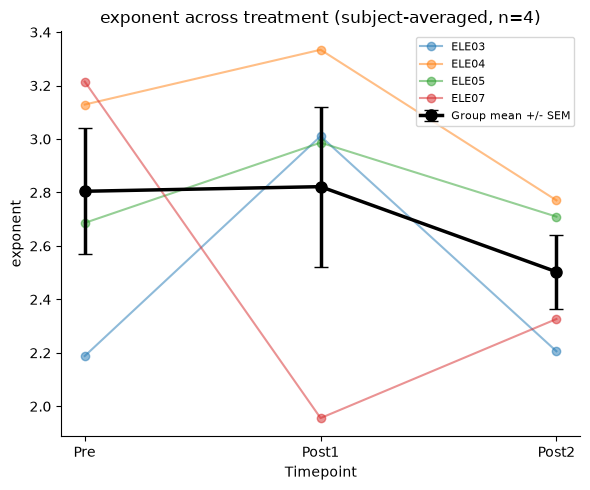

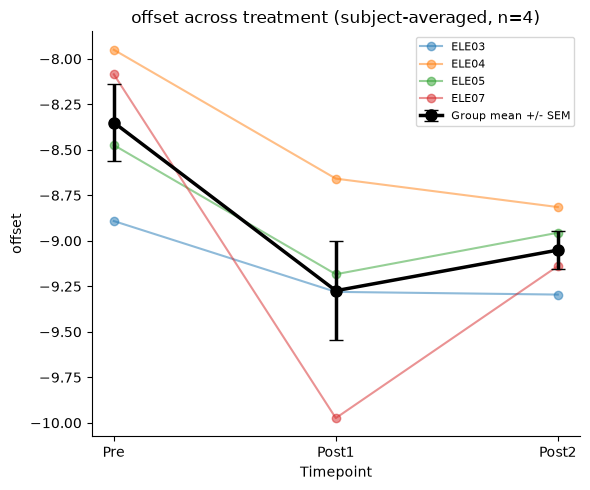

In [14]:
# ----------------------------------------------------------------------
# 7. PLOTTING -- subject-averaged trajectories across Pre/Post1/Post2
# ----------------------------------------------------------------------

def plot_aperiodic_trajectories(results_df, value_col="exponent",
                                 title=None, ylabel=None, save_path=None):
    """
    Spaghetti plot: one line per subject across Pre -> Post1 -> Post2,
    plus the group mean +/- SEM overlaid. This is the honest visual
    complement to run_lme_subject_averaged() -- shows exactly what that
    model is testing (subject-level trajectories), rather than obscuring
    n=4 behind a channel-inflated boxplot.

    Parameters
    ----------
    results_df : DataFrame with subject/timepoint/<value_col> columns.
                 Can be either the raw per-channel results_df (will be
                 averaged per subject automatically) or an already-
                 aggregated one from aggregate_by_subject().
    value_col  : column to plot, e.g. "exponent", "offset"
    save_path  : if given, saves the figure to this path (e.g. "exponent_traj.png")
    """
    import matplotlib.pyplot as plt

    # Auto-detect whether this needs aggregating (per-channel rows present)
    if "channel" in results_df.columns:
        agg = aggregate_by_subject(results_df, value_col=value_col)
    else:
        agg = results_df.copy()
        agg["timepoint"] = pd.Categorical(agg["timepoint"], categories=["Pre", "Post1", "Post2"], ordered=True)

    order = ["Pre", "Post1", "Post2"]
    x_pos = {tp: i for i, tp in enumerate(order)}

    fig, ax = plt.subplots(figsize=(6, 5))

    # Individual subject trajectories (thin, semi-transparent)
    for subject, sub_df in agg.groupby("subject"):
        sub_df = sub_df.sort_values("timepoint")
        xs = [x_pos[tp] for tp in sub_df["timepoint"]]
        ax.plot(xs, sub_df[value_col], marker="o", alpha=0.5, linewidth=1.5,
                label=str(subject))

    # Group mean +/- SEM (bold, on top)
    summary = agg.groupby("timepoint", observed=True)[value_col].agg(["mean", "std", "count"])
    summary["sem"] = summary["std"] / np.sqrt(summary["count"])
    summary = summary.reindex(order)
    xs = [x_pos[tp] for tp in summary.index]
    ax.errorbar(xs, summary["mean"], yerr=summary["sem"], color="black",
                marker="o", markersize=8, linewidth=2.5, capsize=5,
                label="Group mean +/- SEM", zorder=10)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels(order)
    ax.set_xlabel("Timepoint")
    ax.set_ylabel(ylabel or value_col)
    ax.set_title(title or f"{value_col} across treatment (subject-averaged, n={agg['subject'].nunique()})")
    ax.legend(loc="best", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")

    return fig, ax


def plot_periodic_vs_raw_power(aperiodic_df, band_power_df, band="gamma",
                                save_path=None):
    """
    Side-by-side comparison: raw (non-decomposed) band power vs.
    periodic-only band power, subject-averaged, across timepoints. This
    is the actual visual answer to "does the band-power change survive
    removing the aperiodic background".

    Parameters
    ----------
    aperiodic_df   : output of run_pipeline() (has periodic_<band>_power columns)
    band_power_df  : output of extract_band_powers_eses() runs (has raw <band> column)
    band           : which band to compare, e.g. "gamma", "theta"
    """
    import matplotlib.pyplot as plt

    periodic_col = f"periodic_{band}_power"
    raw_agg = aggregate_by_subject(band_power_df, value_col=band)
    periodic_agg = aggregate_by_subject(aperiodic_df, value_col=periodic_col)

    order = ["Pre", "Post1", "Post2"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True)

    for ax, agg, col, subtitle in [
        (axes[0], raw_agg, band, f"Raw {band} power (not decomposed)"),
        (axes[1], periodic_agg, periodic_col, f"Periodic-only {band} power (aperiodic removed)"),
    ]:
        x_pos = {tp: i for i, tp in enumerate(order)}
        for subject, sub_df in agg.groupby("subject"):
            sub_df = sub_df.sort_values("timepoint")
            xs = [x_pos[tp] for tp in sub_df["timepoint"]]
            ax.plot(xs, sub_df[col], marker="o", alpha=0.5, linewidth=1.5, label=str(subject))
        summary = agg.groupby("timepoint", observed=True)[col].agg(["mean", "std", "count"])
        summary["sem"] = summary["std"] / np.sqrt(summary["count"])
        summary = summary.reindex(order)
        xs = [x_pos[tp] for tp in summary.index]
        ax.errorbar(xs, summary["mean"], yerr=summary["sem"], color="black",
                     marker="o", markersize=8, linewidth=2.5, capsize=5, zorder=10)
        ax.set_xticks(list(x_pos.values()))
        ax.set_xticklabels(order)
        ax.set_title(subtitle, fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Power")
    axes[0].legend(loc="best", fontsize=7)
    fig.suptitle(f"{band.capitalize()} band: raw vs. periodic-only power (subject-averaged)")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")

    return fig, axes


if __name__ == "__main__":
    # Step 1: confirm the fixed scalp channel set exists (after alias
    # correction) in every file.
    channels_to_use = validate_channel_set(manifest_csv=MANIFEST_CSV, channel_set=SCALP_CHANNELS)

    # Step 2: real bad-channel check (saturation/flat, exact port of the
    # real pipeline's flag_bad_channels) across all files -- this is
    # informational; load_single_epoch() already drops these channels
    # automatically inside run_pipeline below. Review the printout, and
    # spot-check anything surprising with inspect_raw_for_qc(filepath).
    dropped_df = run_qc_summary(manifest_csv=MANIFEST_CSV)

    # Step 3: run the fit, restricted to the validated channel set. Bad
    # channels (per Step 2) are dropped automatically inside
    # load_single_epoch. Pass exclude=... by hand only for additional
    # channels you catch via visual review that the automated check misses.
    df = run_pipeline(channels_to_use=channels_to_use)

    print("\n--- Aperiodic exponent across timepoints (mean +/- SD, per-channel) ---")
    print(df.groupby("timepoint")["exponent"].agg(["mean", "std", "count"]))

    # Step 4: statistics -- run BOTH per-channel and subject-averaged.
    # Per-channel treats every one of the 19 channels as a separate
    # observation beyond the subject random intercept -- this OVERSTATES
    # confidence (pseudo-replication) and should be read as an exploratory
    # "is the effect spatially consistent within each subject" check, not
    # the primary result. Subject-averaged collapses to one value per
    # subject/timepoint first (honest n=4) -- THIS is the number to trust
    # and report as primary, even though it will likely show weaker
    # significance than the per-channel version.
    for dep_var in ["exponent", "offset"]:
        print("\n" + "=" * 70)
        print(f"PER-CHANNEL LME: {dep_var} ~ timepoint "
              f"(n={len(df)}, exploratory/spatial-consistency check only)")
        print("=" * 70)
        run_lme(df, dependent_var=dep_var)

        print("\n" + "=" * 70)
        print(f"SUBJECT-AVERAGED LME: {dep_var} ~ timepoint "
              f"(n=4 subjects, PRIMARY result)")
        print("=" * 70)
        run_lme_subject_averaged(df, dependent_var=dep_var)

    # Step 5: plots -- subject-averaged trajectories for both metrics
    plot_aperiodic_trajectories(df, value_col="exponent",
                                 save_path="exponent_trajectories.png")
    plot_aperiodic_trajectories(df, value_col="offset",
                                 save_path="offset_trajectories.png")
    import os
df = run_pipeline(channels_to_use=channels_to_use)

print("Working directory:", os.getcwd())
print("Full path of the file just written:", os.path.abspath("aperiodic_results.csv"))
print("File modified at:", pd.Timestamp.fromtimestamp(os.path.getmtime("aperiodic_results.csv")))
print()
print("Values directly from the df just returned (not re-read from disk):")
print(df[(df.subject=='ELE03')&(df.timepoint=='Post1')][['exponent','offset']].mean())


  OK: ELE03 / Pre has all 19 channels
  [J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2-Post1.edf] both mastoid channels bad/missing -- using average reference fallback instead of linked mastoid
  OK: ELE03 / Post1 has all 19 channels
  OK: ELE03 / Post2 has all 19 channels
  OK: ELE04 / Pre has all 19 channels
  OK: ELE04 / Post1 has all 19 channels
  OK: ELE04 / Post2 has all 19 channels
  OK: ELE05 / Pre has all 19 channels
  OK: ELE05 / Post1 has all 19 channels
  OK: ELE05 / Post2 has all 19 channels
  OK: ELE07 / Pre has all 19 channels
  OK: ELE07 / Post1 has all 19 channels
  OK: ELE07 / Post2 has all 19 channels

All files contain all 19 channels in the requested set.
  ELE03 / Pre: clean (no bad channels)
  [J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2-Post1.edf] both mastoid channels bad/missing -- using average reference fallback in

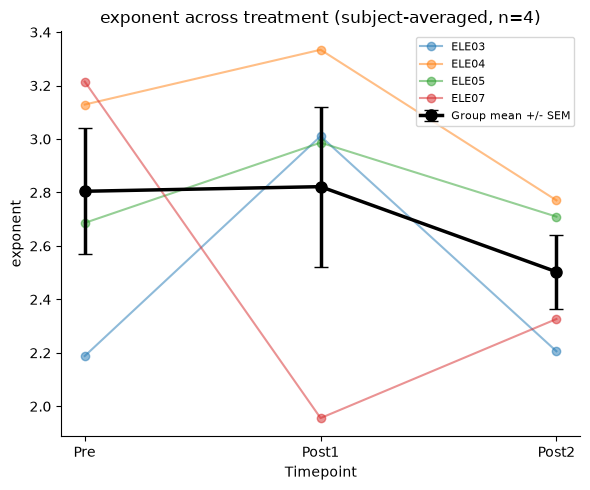

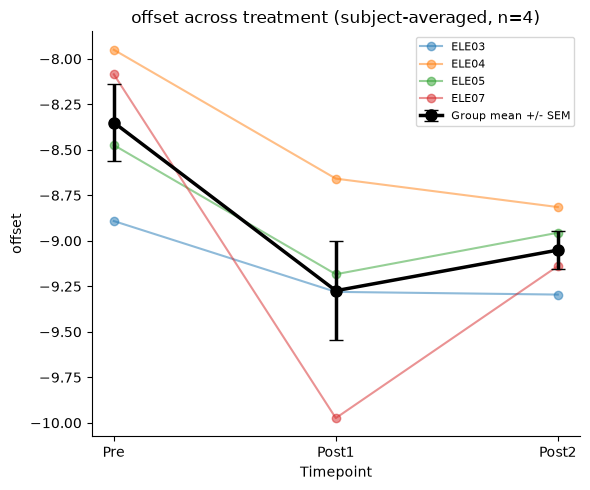

In [ ]:
# ----------------------------------------------------------------------
# 7b. MNE TOPOMAP PLOTTING -- spatial (scalp) view of the results
# ----------------------------------------------------------------------
# The trajectory plots above show WHEN the effect happens; these show
# WHERE on the scalp it happens -- a genuinely different, complementary
# view, since SCALP_CHANNELS covers real 10-20 positions MNE can plot
# directly against a head outline.
 
def _build_topomap_info(ch_names):
    """
    Build a minimal MNE Info with a standard 10-20 montage attached, for
    topomap plotting.
 
    IMPORTANT: ch_names must be passed in with their REAL case as they
    appear in your results_df (e.g. "Cz", "Fp1"), NOT SCALP_CHANNELS
    (which stores "CZ", "FP1" in all-caps for internal matching purposes
    only). Confirmed via testing: passing SCALP_CHANNELS directly here
    caused a silent case-sensitive reindex mismatch downstream (5 of 19
    channels -> NaN), which was enough to break the topomap's interpolated
    surface entirely (blank plots, sensors/outline only) -- match_case=False
    only affects montage lookup, not the later data-to-channel alignment.
    """
    info = mne.create_info(list(ch_names), sfreq=256, ch_types="eeg")
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, match_case=True, on_missing="warn")
    return info
 
 
def plot_topomap_by_timepoint(results_df, value_col="exponent",
                               cmap="RdBu_r", save_path=None):
    """
    One topomap per timepoint (Pre, Post1, Post2), value averaged across
    subjects for each channel -- shows the spatial pattern of the
    aperiodic parameter at each stage of treatment, on a shared color
    scale so the three panels are directly comparable.
    """
    import matplotlib.pyplot as plt
 
    # channel x timepoint mean across subjects (build Info from the
    # ACTUAL channel names present, correct case, avoiding the mismatch)
    ch_tp_mean = results_df.groupby(["channel", "timepoint"])[value_col].mean().unstack()
    ch_tp_mean = ch_tp_mean.reindex(columns=["Pre", "Post1", "Post2"])
    info = _build_topomap_info(sorted(ch_tp_mean.index))
    ch_tp_mean = ch_tp_mean.reindex(info["ch_names"])
 
    order = ["Pre", "Post1", "Post2"]
    vmin = ch_tp_mean.min().min()
    vmax = ch_tp_mean.max().max()
    assert not ch_tp_mean.isna().any().any(), \
        "NaN present after alignment -- channel name mismatch still exists, check results_df['channel'] values"
 
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, tp in zip(axes, order):
        data = ch_tp_mean[tp].values
        im, _ = mne.viz.plot_topomap(data, info, axes=ax, show=False,
                                      cmap=cmap, vlim=(vmin, vmax),
                                      sensors=True, contours=4)
        ax.set_title(tp)
 
    cbar = fig.colorbar(im, ax=axes, shrink=0.7, label=value_col)
    fig.suptitle(f"{value_col} by scalp location (subject-averaged, n={results_df['subject'].nunique()})")
 
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")
 
    return fig, axes
 
 
def plot_topomap_difference(results_df, value_col="exponent",
                             timepoint_a="Pre", timepoint_b="Post2",
                             cmap="RdBu_r", save_path=None):
    """
    Single topomap of (timepoint_b - timepoint_a), per channel, averaged
    across subjects -- shows WHERE the treatment-related change is
    concentrated on the scalp, rather than just that it happened.
    Diverging colormap centered at zero so blue/red directly indicate
    decrease/increase.
    """
    import matplotlib.pyplot as plt
 
    ch_tp_mean = results_df.groupby(["channel", "timepoint"])[value_col].mean().unstack()
    diff = ch_tp_mean[timepoint_b] - ch_tp_mean[timepoint_a]
    info = _build_topomap_info(sorted(diff.index))
    diff = diff.reindex(info["ch_names"])
    assert not diff.isna().any(), \
        "NaN present after alignment -- channel name mismatch still exists, check results_df['channel'] values"
 
    vabs = float(diff.abs().max())
 
    fig, ax = plt.subplots(figsize=(5, 5))
    im, _ = mne.viz.plot_topomap(diff.values, info, axes=ax, show=False,
                                  cmap=cmap, vlim=(-vabs, vabs),
                                  sensors=True, contours=4)
    ax.set_title(f"{value_col}: {timepoint_b} - {timepoint_a}\n(subject-averaged, n={results_df['subject'].nunique()})")
    fig.colorbar(im, ax=ax, shrink=0.8, label=f"Δ {value_col}")
 
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")
 
    return fig, ax
 
 
if __name__ == "__main__":
    # Step 1: confirm the fixed scalp channel set exists (after alias
    # correction) in every file.
    channels_to_use = validate_channel_set(manifest_csv=MANIFEST_CSV, channel_set=SCALP_CHANNELS)
 
    # Step 2: real bad-channel check (saturation/flat, exact port of the
    # real pipeline's flag_bad_channels) across all files -- this is
    # informational; load_single_epoch() already drops these channels
    # automatically inside run_pipeline below. Review the printout, and
    # spot-check anything surprising with inspect_raw_for_qc(filepath).
    dropped_df = run_qc_summary(manifest_csv=MANIFEST_CSV)
 
    # Step 3: run the fit, restricted to the validated channel set. Bad
    # channels (per Step 2) are dropped automatically inside
    # load_single_epoch. Pass exclude=... by hand only for additional
    # channels you catch via visual review that the automated check misses.
    df = run_pipeline(channels_to_use=channels_to_use)
 
    print("\n--- Aperiodic exponent across timepoints (mean +/- SD, per-channel) ---")
    print(df.groupby("timepoint")["exponent"].agg(["mean", "std", "count"]))
 
    # Step 4: statistics -- run BOTH per-channel and subject-averaged.
    # Per-channel treats every one of the 19 channels as a separate
    # observation beyond the subject random intercept -- this OVERSTATES
    # confidence (pseudo-replication) and should be read as an exploratory
    # "is the effect spatially consistent within each subject" check, not
    # the primary result. Subject-averaged collapses to one value per
    # subject/timepoint first (honest n=4) -- THIS is the number to trust
    # and report as primary, even though it will likely show weaker
    # significance than the per-channel version.
    for dep_var in ["exponent", "offset"]:
        print("\n" + "=" * 70)
        print(f"PER-CHANNEL LME: {dep_var} ~ timepoint "
              f"(n={len(df)}, exploratory/spatial-consistency check only)")
        print("=" * 70)
        run_lme(df, dependent_var=dep_var)
 
        print("\n" + "=" * 70)
        print(f"SUBJECT-AVERAGED LME: {dep_var} ~ timepoint "
              f"(n=4 subjects, PRIMARY result)")
        print("=" * 70)
        run_lme_subject_averaged(df, dependent_var=dep_var)



In [20]:
df[(df.subject=='ELE03')&(df.timepoint=='Post1')][['exponent','offset']].mean()

exponent    3.010716
offset     -9.280541
dtype: float64

Saved to topomap_exponent_by_tp.png
Saved to topomap_offset_by_tp.png
Saved to topomap_offset_diff.png
Saved to topomap_exponent_diff.png


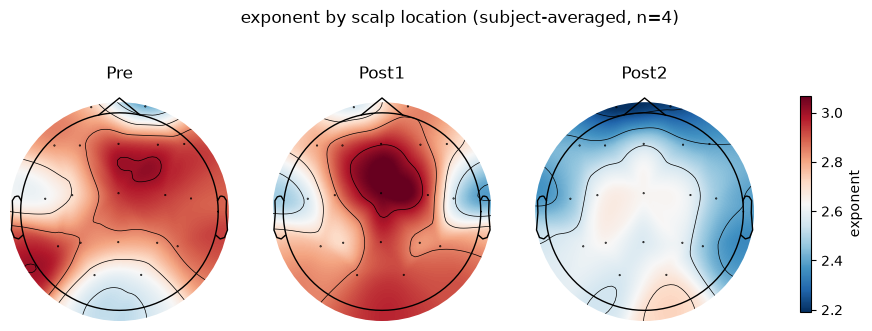

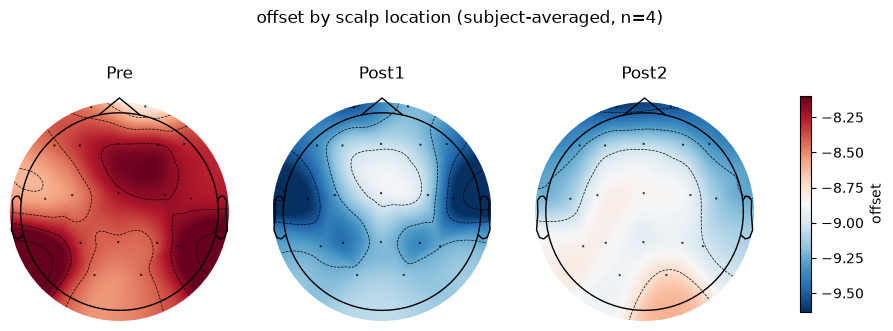

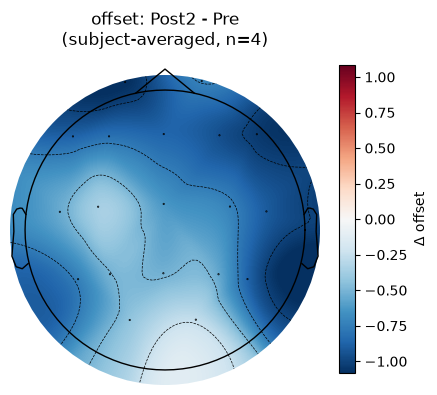

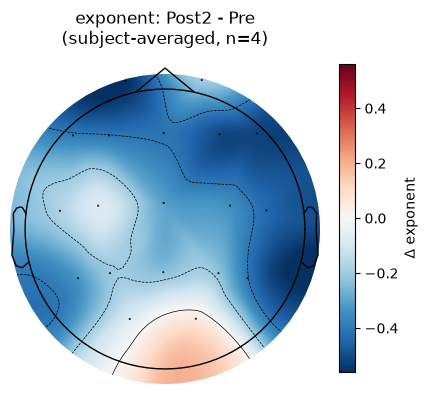

In [ ]:
plot_aperiodic_trajectories(df, value_col="exponent", save_path="exponent_trajectories.png")
plot_aperiodic_trajectories(df, value_col="offset", save_path="offset_trajectories.png")
fig, axes = plot_topomap_by_timepoint(df, value_col="exponent", save_path="topomap_exponent_by_tp.png")
fig, axes = plot_topomap_by_timepoint(df, value_col="offset", save_path="topomap_offset_by_tp.png")
fig, ax = plot_topomap_difference(df, value_col="offset", timepoint_a="Pre", timepoint_b="Post2", save_path="topomap_offset_diff.png")
fig, ax = plot_topomap_difference(df, value_col="exponent", timepoint_a="Pre", timepoint_b="Post2", save_path="topomap_exponent_diff.png")

In [29]:
# ----------------------------------------------------------------------
# 8. SPATIAL STATISTICS -- is the topomap pattern real or channel noise?
# ----------------------------------------------------------------------
# CRITICAL LIMITATION, stated up front: with n=4 subjects, a paired
# sign-flip permutation test has only 2^4=16 possible permutations, so
# the smallest achievable p-value is 1/16 = 0.0625 -- ABOVE the
# conventional 0.05 threshold before any data are even looked at. No
# channel or cluster can reach "significant" by that convention at this
# sample size. Both functions below still report real effect sizes and
# exact minimal-achievable p-values honestly; treat any "p=0.0625" result
# as "the strongest possible evidence obtainable at this n", not as a
# non-finding.
 
def run_channel_paired_test(results_df, value_col="exponent",
                             timepoint_a="Pre", timepoint_b="Post2"):
    """
    Per-channel paired t-test (timepoint_b - timepoint_a, subject-averaged
    first so each subject contributes one paired difference per channel),
    with Benjamini-Hochberg FDR correction across the 19 channels.
 
    This does NOT account for spatial adjacency between channels (each
    channel tested independently, only corrected for the number of
    tests) -- use run_cluster_permutation_test() below for a spatially-
    aware test. This one is easier to interpret per-channel and doesn't
    hit the extreme permutation-count limitation the cluster test does.
 
    Returns
    -------
    DataFrame: channel, mean_diff, t_stat, p_value, p_fdr
    """
    from scipy.stats import ttest_rel
    from statsmodels.stats.multitest import multipletests
 
    agg = results_df.groupby(["subject", "channel", "timepoint"])[value_col].mean().unstack("timepoint")
    channels = sorted(agg.index.get_level_values("channel").unique())
 
    rows = []
    for ch in channels:
        sub = agg.xs(ch, level="channel")
        a = sub[timepoint_a].values
        b = sub[timepoint_b].values
        valid = ~(np.isnan(a) | np.isnan(b))
        if valid.sum() < 2:
            rows.append({"channel": ch, "mean_diff": np.nan, "t_stat": np.nan, "p_value": np.nan})
            continue
        t_stat, p_val = ttest_rel(b[valid], a[valid])
        rows.append({"channel": ch, "mean_diff": float(np.mean(b[valid] - a[valid])),
                     "t_stat": t_stat, "p_value": p_val, "n": int(valid.sum())})
 
    df = pd.DataFrame(rows)
    valid_p = df["p_value"].notna()
    df.loc[valid_p, "p_fdr"] = multipletests(df.loc[valid_p, "p_value"], method="fdr_bh")[1]
 
    print(f"--- Per-channel paired test: {value_col}, {timepoint_b} vs {timepoint_a} "
          f"(n={df['n'].iloc[0] if len(df) else '?'} subjects, FDR-corrected across {len(df)} channels) ---")
    print(df.sort_values("p_value").to_string(index=False))
    print("\nNOTE: with n=4 subjects, statistical power is inherently limited -- "
          "treat uncorrected p-values as indicative, p_fdr as the honest number.")
    return df
 
 
def run_cluster_permutation_test(results_df, value_col="exponent",
                                  timepoint_a="Pre", timepoint_b="Post2",
                                  p_threshold=0.05, n_permutations="all",
                                  cluster_threshold=None):
    """
    Spatially-aware cluster-based permutation test (MNE's
    permutation_cluster_1samp_test) on the paired difference
    (timepoint_b - timepoint_a) per subject per channel. Forms clusters
    of spatially ADJACENT channels whose |t-value| exceeds
    cluster_threshold, then tests cluster-mass significance via sign-flip
    permutation -- this is the standard way to test "is this spatial
    pattern real" while correcting for multiple comparisons in a way that
    respects scalp topology (a real physiological effect should span
    adjacent channels, unlike noise).
 
    cluster_threshold : the per-channel |t| cutoff for a channel to even
        be considered for cluster membership. MNE's default (None) picks
        a fairly strict value (~p<0.05 uncorrected, df=n_subjects-1) --
        with n=4 (df=3) that can be strict enough that NO channel clears
        it, meaning zero candidate clusters form and there is no p-value
        to report at all (confirmed: this happened for exponent in your
        real data). Defaulting here to 1.0 (lenient) so weak candidate
        clusters still form and get an actual, honestly-reported p-value
        -- even if non-significant, "p=0.375" is more informative than
        no cluster existing to test. Raise this value for a stricter,
        more conventional cluster-forming criterion if preferred.
 
    LIMITATION: with n=4 subjects, sign-flipping gives only 2^4=16
    possible permutations. n_permutations="all" uses all of them --
    smallest achievable p-value is 1/16=0.0625, above p<0.05. This
    function will very likely find no "significant" cluster at this n;
    report the actual cluster masses and p-values as the honest answer
    rather than expecting significance.
 
    Returns
    -------
    dict with keys: t_obs (per-channel t-values), clusters (list of
    channel-index arrays), cluster_p_values, info (for plotting), and
    a channels_in_significant_clusters list (empty if none reach
    p < p_threshold -- expected given the n=4 limitation above).
    """
    agg = results_df.groupby(["subject", "channel", "timepoint"])[value_col].mean().unstack("timepoint")
    channels = sorted(agg.index.get_level_values("channel").unique())
    subjects = sorted(agg.index.get_level_values("subject").unique())
 
    # Build subject x channel difference matrix
    X = np.full((len(subjects), len(channels)), np.nan)
    for i, s in enumerate(subjects):
        for j, ch in enumerate(channels):
            try:
                row = agg.xs((s, ch))
                X[i, j] = row[timepoint_b] - row[timepoint_a]
            except KeyError:
                pass
 
    if np.isnan(X).any():
        raise ValueError(f"Missing data for some subject/channel combinations -- "
                          f"{np.isnan(X).sum()} NaN cells. Check that every subject "
                          f"has every channel at both {timepoint_a} and {timepoint_b}.")
 
    info = _build_topomap_info(channels)
    adjacency, adj_ch_names = mne.channels.find_ch_adjacency(info, ch_type="eeg")
    assert adj_ch_names == channels, "Channel order mismatch between adjacency and data matrix"
 
    n_subjects = X.shape[0]
    max_permutations = 2 ** n_subjects
    if n_permutations == "all" or (isinstance(n_permutations, int) and n_permutations > max_permutations):
        n_permutations = max_permutations
        print(f"n={n_subjects} subjects -> using all {max_permutations} possible sign-flip "
              f"permutations (minimum achievable p-value = 1/{max_permutations} = "
              f"{1/max_permutations:.4f})")
 
    t_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
        X, threshold=cluster_threshold, n_permutations=n_permutations, tail=0,
        adjacency=adjacency, seed=42, out_type="indices", verbose=False,
    )
 
    print(f"\n--- Cluster permutation test: {value_col}, {timepoint_b} vs {timepoint_a} ---")
    sig_clusters = []
    for i, (cl, p) in enumerate(zip(clusters, cluster_p_values)):
        ch_in_cluster = [channels[idx] for idx in cl[0]]
        marker = " <-- p < 0.05" if p < p_threshold else ""
        print(f"  Cluster {i}: channels={ch_in_cluster}, size={len(ch_in_cluster)}, p={p:.4f}{marker}")
        if p < p_threshold:
            sig_clusters.extend(ch_in_cluster)
 
    if not sig_clusters:
        print(f"\n  No cluster reached p < {p_threshold} -- expected given n={n_subjects} "
              f"(minimum achievable p = {1/max_permutations:.4f}). Report the smallest "
              f"cluster p-value found as the honest result, not as a null finding.")
 
    return {
        "t_obs": t_obs, "clusters": clusters, "cluster_p_values": cluster_p_values,
        "channels": channels, "info": info,
        "channels_in_significant_clusters": sig_clusters,
    }
 
 
def cluster_result_to_df(cluster_result, value_col, comparison_label):
    """
    Convert a run_cluster_permutation_test() dict into a flat, savable
    DataFrame -- one row per cluster, with the channels in that cluster
    joined into a single string column (so it survives a CSV round-trip
    cleanly, unlike a raw Python list).
 
    NOTE: if no channel cleared the cluster-forming threshold, this will
    have exactly one placeholder row with no cluster/p-value -- that's
    not a display bug, it means no candidate cluster existed to test at
    all. See cluster_tvalues_to_df() below for the per-channel t-values,
    which ARE always computed regardless of whether any cluster formed.
    """
    rows = []
    for i, (cl, p) in enumerate(zip(cluster_result["clusters"], cluster_result["cluster_p_values"])):
        ch_in_cluster = [cluster_result["channels"][idx] for idx in cl[0]]
        rows.append({
            "value_col": value_col, "comparison": comparison_label,
            "cluster_id": i, "n_channels": len(ch_in_cluster),
            "channels": ",".join(ch_in_cluster), "p_value": p,
            "significant_p<0.05": p < 0.05,
        })
    if not rows:
        rows.append({"value_col": value_col, "comparison": comparison_label,
                      "cluster_id": None, "n_channels": 0, "channels": "",
                      "p_value": None, "significant_p<0.05": False})
    return pd.DataFrame(rows)
 
 
def cluster_tvalues_to_df(cluster_result, value_col, comparison_label):
    """
    Per-channel t-values (t_obs) from a run_cluster_permutation_test()
    result -- one row per channel. These are ALWAYS computed for every
    channel regardless of whether that channel ended up in a cluster,
    unlike cluster-level p-values which only exist for channels that
    cleared the cluster-forming threshold. Use this when you want to see
    a real number for every channel, not just the ones that happened to
    form a cluster.
    """
    return pd.DataFrame({
        "value_col": value_col, "comparison": comparison_label,
        "channel": cluster_result["channels"],
        "t_value": cluster_result["t_obs"],
    })
 
 
def export_spatial_stats_results(results, output_dir="."):
    """
    Save every paired-test and cluster-test result to CSV in output_dir
    (defaults to the current working directory -- same folder as
    aperiodic_results.csv and the topomap PNGs, per your workflow).
 
    Parameters
    ----------
    results : dict mapping a label (e.g. "offset_pre_post1_paired") to
        either a DataFrame (from run_channel_paired_test) or a dict
        (from run_cluster_permutation_test) -- both types handled
        automatically.
    output_dir : folder to save into. "." = current working directory.
 
    Example
    -------
    export_spatial_stats_results({
        "offset_pre_post1_paired": paired_offset_p1,
        "offset_pre_post1_cluster": cluster_offset_p1,
        "offset_pre_post2_paired": paired_offset_p2,
        "offset_pre_post2_cluster": cluster_offset_p2,
        "exponent_pre_post1_paired": paired_exp_p1,
        "exponent_pre_post1_cluster": cluster_exp_p1,
        "exponent_pre_post2_paired": paired_exp_p2,
        "exponent_pre_post2_cluster": cluster_exp_p2,
    })
    """
    import os
    saved = []
    for label, result in results.items():
        if isinstance(result, pd.DataFrame):
            path = os.path.join(output_dir, f"spatial_stats_{label}.csv")
            result.to_csv(path, index=False)
            saved.append(path)
            print(f"  Saved {os.path.abspath(path)}")
        elif isinstance(result, dict) and "clusters" in result:
            value_col = label.split("_")[0]
 
            # cluster-level table (one row per cluster; empty placeholder
            # row if no cluster formed at all -- see cluster_result_to_df docstring)
            cluster_path = os.path.join(output_dir, f"spatial_stats_{label}.csv")
            cluster_result_to_df(result, value_col, label).to_csv(cluster_path, index=False)
            saved.append(cluster_path)
            print(f"  Saved {os.path.abspath(cluster_path)}")
 
            # per-channel t-values table (ALWAYS has real numbers, one
            # per channel, regardless of whether any cluster formed)
            tval_path = os.path.join(output_dir, f"spatial_stats_{label}_tvalues.csv")
            cluster_tvalues_to_df(result, value_col, label).to_csv(tval_path, index=False)
            saved.append(tval_path)
            print(f"  Saved {os.path.abspath(tval_path)}")
        else:
            print(f"  Skipped '{label}': unrecognized result type ({type(result)})")
            continue
 
    print(f"\nSaved {len(saved)} file(s) to {os.path.abspath(output_dir)}")
    return saved
 
 
if __name__ == "__main__":
    # Step 1: confirm the fixed scalp channel set exists (after alias
    # correction) in every file.
    channels_to_use = validate_channel_set(manifest_csv=MANIFEST_CSV, channel_set=SCALP_CHANNELS)
 
    # Step 2: real bad-channel check (saturation/flat, exact port of the
    # real pipeline's flag_bad_channels) across all files -- this is
    # informational; load_single_epoch() already drops these channels
    # automatically inside run_pipeline below. Review the printout, and
    # spot-check anything surprising with inspect_raw_for_qc(filepath).
    dropped_df = run_qc_summary(manifest_csv=MANIFEST_CSV)
 
    # Step 3: run the fit, restricted to the validated channel set. Bad
    # channels (per Step 2) are dropped automatically inside
    # load_single_epoch. Pass exclude=... by hand only for additional
    # channels you catch via visual review that the automated check misses.
    df = run_pipeline(channels_to_use=channels_to_use)
 
    print("\n--- Aperiodic exponent across timepoints (mean +/- SD, per-channel) ---")
    print(df.groupby("timepoint")["exponent"].agg(["mean", "std", "count"]))
 
    # Step 4: statistics -- run BOTH per-channel and subject-averaged.
    # Per-channel treats every one of the 19 channels as a separate
    # observation beyond the subject random intercept -- this OVERSTATES
    # confidence (pseudo-replication) and should be read as an exploratory
    # "is the effect spatially consistent within each subject" check, not
    # the primary result. Subject-averaged collapses to one value per
    # subject/timepoint first (honest n=4) -- THIS is the number to trust
    # and report as primary, even though it will likely show weaker
    # significance than the per-channel version.
    for dep_var in ["exponent", "offset"]:
        print("\n" + "=" * 70)
        print(f"PER-CHANNEL LME: {dep_var} ~ timepoint "
              f"(n={len(df)}, exploratory/spatial-consistency check only)")
        print("=" * 70)
        run_lme(df, dependent_var=dep_var)
 
        print("\n" + "=" * 70)
        print(f"SUBJECT-AVERAGED LME: {dep_var} ~ timepoint "
              f"(n=4 subjects, PRIMARY result)")
        print("=" * 70)
        run_lme_subject_averaged(df, dependent_var=dep_var)
 

  OK: ELE03 / Pre has all 19 channels
  [J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2-Post1.edf] both mastoid channels bad/missing -- using average reference fallback instead of linked mastoid
  OK: ELE03 / Post1 has all 19 channels
  OK: ELE03 / Post2 has all 19 channels
  OK: ELE04 / Pre has all 19 channels
  OK: ELE04 / Post1 has all 19 channels
  OK: ELE04 / Post2 has all 19 channels
  OK: ELE05 / Pre has all 19 channels
  OK: ELE05 / Post1 has all 19 channels
  OK: ELE05 / Post2 has all 19 channels
  OK: ELE07 / Pre has all 19 channels
  OK: ELE07 / Post1 has all 19 channels
  OK: ELE07 / Post2 has all 19 channels

All files contain all 19 channels in the requested set.
  ELE03 / Pre: clean (no bad channels)
  [J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2-Post1.edf] both mastoid channels bad/missing -- using average reference fallback in

In [31]:
# ============================================================
# OFFSET -- your robust, significant finding
# ============================================================
print("########## OFFSET: Pre vs Post1 ##########")
paired_offset_p1 = run_channel_paired_test(df, value_col="offset", timepoint_a="Pre", timepoint_b="Post1")
cluster_offset_p1 = run_cluster_permutation_test(df, value_col="offset", timepoint_a="Pre", timepoint_b="Post1")

print("\n########## OFFSET: Pre vs Post2 ##########")
paired_offset_p2 = run_channel_paired_test(df, value_col="offset", timepoint_a="Pre", timepoint_b="Post2")
cluster_offset_p2 = run_cluster_permutation_test(df, value_col="offset", timepoint_a="Pre", timepoint_b="Post2")

# ============================================================
# EXPONENT -- your weaker, more spatially heterogeneous finding
# ============================================================
print("\n########## EXPONENT: Pre vs Post1 ##########")
paired_exp_p1 = run_channel_paired_test(df, value_col="exponent", timepoint_a="Pre", timepoint_b="Post1")
cluster_exp_p1 = run_cluster_permutation_test(df, value_col="exponent", timepoint_a="Pre", timepoint_b="Post1")

print("\n########## EXPONENT: Pre vs Post2 ##########")
paired_exp_p2 = run_channel_paired_test(df, value_col="exponent", timepoint_a="Pre", timepoint_b="Post2")
cluster_exp_p2 = run_cluster_permutation_test(df, value_col="exponent", timepoint_a="Pre", timepoint_b="Post2")

export_spatial_stats_results({
    "offset_pre_post1_paired": paired_offset_p1,
    "offset_pre_post1_cluster": cluster_offset_p1,
    "offset_pre_post2_paired": paired_offset_p2,
    "offset_pre_post2_cluster": cluster_offset_p2,
    "exponent_pre_post1_paired": paired_exp_p1,
    "exponent_pre_post1_cluster": cluster_exp_p1,
    "exponent_pre_post2_paired": paired_exp_p2,
    "exponent_pre_post2_cluster": cluster_exp_p2,
})

########## OFFSET: Pre vs Post1 ##########
--- Per-channel paired test: offset, Post1 vs Pre (n=4 subjects, FDR-corrected across 19 channels) ---
channel  mean_diff    t_stat  p_value  n    p_fdr
     P7  -1.223443 -6.306606 0.008056  4 0.077411
     P8  -1.118741 -6.281137 0.008149  4 0.077411
     T8  -1.386143 -3.514934 0.039059  4 0.131677
     C4  -0.906899 -3.368879 0.043447  4 0.131677
     F3  -0.808642 -3.356971 0.043832  4 0.131677
     T7  -1.065122 -3.356104 0.043860  4 0.131677
     F7  -0.920288 -3.221937 0.048513  4 0.131677
    Fp1  -1.025116 -2.733289 0.071742  4 0.170387
     F8  -1.092548 -2.463881 0.090555  4 0.191171
     P3  -1.103907 -2.080947 0.128886  4 0.225376
     Fz  -0.842237 -2.052799 0.132408  4 0.225376
     P4  -0.990781 -1.977936 0.142343  4 0.225376
     C3  -0.777955 -1.880289 0.156650  4 0.228950
     F4  -0.945553 -1.700258 0.187641  4 0.249084
     Pz  -0.776468 -1.642343 0.199060  4 0.249084
    Fp2  -0.439963 -1.577253 0.212837  4 0.249084
    

['.\\spatial_stats_offset_pre_post1_paired.csv',
 '.\\spatial_stats_offset_pre_post1_cluster.csv',
 '.\\spatial_stats_offset_pre_post1_cluster_tvalues.csv',
 '.\\spatial_stats_offset_pre_post2_paired.csv',
 '.\\spatial_stats_offset_pre_post2_cluster.csv',
 '.\\spatial_stats_offset_pre_post2_cluster_tvalues.csv',
 '.\\spatial_stats_exponent_pre_post1_paired.csv',
 '.\\spatial_stats_exponent_pre_post1_cluster.csv',
 '.\\spatial_stats_exponent_pre_post1_cluster_tvalues.csv',
 '.\\spatial_stats_exponent_pre_post2_paired.csv',
 '.\\spatial_stats_exponent_pre_post2_cluster.csv',
 '.\\spatial_stats_exponent_pre_post2_cluster_tvalues.csv']